In [6]:
import jax
import jax.numpy as jnp
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns  

import liesel.model as lsl
import liesel.goose as gs
from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

In [7]:
# ==========================================
# 1. FACTORY FUNCTIONS
# ==========================================
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df, 
        scale_tril=scale_tril, 
        input_output_cholesky=True, 
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

In [8]:
# ==========================================
# 2. DATA LOADING (Replaces Simulation)
# ==========================================
def load_camera_data(filepath):
    with open(filepath, 'r') as f:
        raw_data = json.load(f)
    
    X_list = []
    y_list = []
    unit_indices = []
    
    # bayesm 'camera' data specifics
    n_alts = 5  # Canon, Sony, Nikon, Panasonic, Fuji
    
    for i, respondent in enumerate(raw_data):
        # R exports matrices as flat lists or lists of lists depending on settings
        # We assume standard structure: X is (n_obs * n_alts, n_params)
        X_raw = np.array(respondent['X'])
        y_raw = np.array(respondent['y'])
        
        # Determine dimensions
        n_choice_occasions = len(y_raw)
        n_params = X_raw.shape[1]
        
        # RESHAPE X: 
        # R bayesm format is stacked: (Obs1_Alt1, Obs1_Alt2... ObsN_Alt5)
        # We need: (Obs, Alts, Params)
        X_reshaped = X_raw.reshape((n_choice_occasions, n_alts, n_params))
        
        # ADJUST Y:
        # R uses 1-based indexing (1 to 5). Python needs 0 to 4.
        y_adjusted = y_raw - 1
        
        X_list.append(X_reshaped)
        y_list.append(y_adjusted)
        unit_indices.extend([i] * n_choice_occasions)

    return {
        "X": jnp.array(np.concatenate(X_list, axis=0)),
        "y": jnp.array(np.concatenate(y_list, axis=0)),
        "unit_idx": jnp.array(unit_indices),
        "n_units": len(raw_data),
        "n_params": X_list[0].shape[2]
    }

# Load the real data
print("Loading camera data...")
data_dict = load_camera_data("../Data/camera_data.json")

k_dim = int(data_dict["n_params"]) # Should be roughly 10-13 for camera data
n_units = int(data_dict["n_units"]) # Should be 332

print(f"Data Loaded: {n_units} units, {k_dim} parameters.")
print(f"Total Observations: {data_dict['y'].shape[0]}")

Loading camera data...
Data Loaded: 332 units, 10 parameters.
Total Observations: 5312


In [9]:
# ==========================================
# 3. MODEL BUILDING
# ==========================================

# Constants
nu_val = float(k_dim + 3)
V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)
A_val = 0.01
zero_loc_val = jnp.zeros(k_dim)

# Parameters
sigma_inv_chol = lsl.Var.new_param(
    value=jnp.eye(k_dim),
    distribution=lsl.Dist(make_wishart, df=nu_val, scale_tril=Vinv_chol_val),
    name="sigma_inv_chol"
)

sigma_inv_chol_latent = sigma_inv_chol.transform(
    tfb.FillScaleTriL(), 
    name="sigma_inv_chol_latent"
)

mu_prec_factor = lsl.Var.new_calc(
    lambda L: jnp.sqrt(A_val) * L, 
    L=sigma_inv_chol, 
    name="mu_prec_factor"
)

mu = lsl.Var.new_param(
    value=jnp.zeros(k_dim),
    distribution=lsl.Dist(make_mvn_precision, loc=zero_loc_val, precision_factor=mu_prec_factor),
    name="mu"
)

# Initialize betas closer to zero to avoid huge initial gradients
beta_i = lsl.Var.new_param(
    value=jnp.zeros((n_units, k_dim)),
    distribution=lsl.Dist(make_mvn_precision, loc=mu, precision_factor=sigma_inv_chol),
    name="beta_i"
)

# Observation Model
X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")

beta_expanded = lsl.Var.new_calc(
    lambda b, idx: b[idx], 
    b=beta_i, 
    idx=idx_var, 
    name="beta_expanded"
)

# Multinomial Logit Logic
# X is (N, Alts, K), Beta is (N, K). 
# We want logits (N, Alts). 
# Einstein summation: n=obs, i=alts, j=params
logits = lsl.Var.new_calc(
    lambda x, b: jnp.einsum("nij,nj->ni", x, b), 
    x=X_var, 
    b=beta_expanded, 
    name="logits"
)

y_var = lsl.Var.new_obs(
    data_dict["y"], 
    distribution=lsl.Dist(tfd.Categorical, logits=logits), 
    name="y"
)

model = lsl.Model([y_var])

In [10]:
# ==========================================
# 4. INFERENCE
# ==========================================
eb = gs.EngineBuilder(seed=123, num_chains=4)
eb.set_model(gs.LieselInterface(model))
eb.set_initial_values(model.state)

eb.add_kernel(gs.NUTSKernel(["mu"]))
eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
eb.add_kernel(gs.NUTSKernel(["beta_i"]))

# Duration: Adjusted for real data (might need longer warmup)
eb.set_duration(warmup_duration=1000, posterior_duration=2000)

print("Starting Sampling...")
engine = eb.build()
engine.sample_all_epochs()

results = engine.get_results()
samples = results.get_posterior_samples()

liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting Sampling...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:19<00:00,  6.51s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 4, 4, 2, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 7, 11, 8, 9 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 3, 2, 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 512.50chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2, 1, 2, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 2, 1, 4, 4 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1, 1, 2, 1 / 25 transitions
liesel.goose.

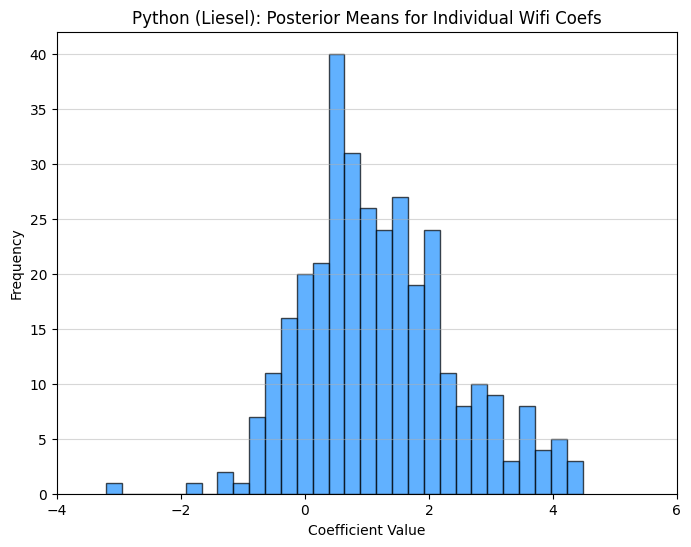


Global Posterior Means (Mu):
[ 2.0084903  1.5758785  1.7021132  1.1798512  1.4276644  1.7538158
  1.3366174  0.7656956  1.2013302 -3.5810359]


In [11]:
# ==========================================
# 5. ANALYSIS & COMPARISON
# ==========================================

# Calculate Posterior Means for Beta_i
# Shape: (chains, samples, units, params) -> mean over (chains, samples)
beta_means = jnp.mean(samples["beta_i"], axis=(0, 1)) 

# Comparison Plot
# R code: hist(..., [,9]) -> This is the 9th column (Wifi coefficient)
# Python is 0-indexed, so we want index 8.

wifi_coef_index = 8 

plt.figure(figsize=(8, 6))
plt.hist(beta_means[:, wifi_coef_index], bins=30, color='dodgerblue', alpha=0.7, edgecolor='black')
plt.title("Python (Liesel): Posterior Means for Individual Wifi Coefs")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.xlim(-4, 6) # Matching R plot limits
plt.grid(axis='y', alpha=0.5)
plt.show()

print("\nGlobal Posterior Means (Mu):")
print(jnp.mean(samples["mu"], axis=(0,1)))

### COMPARISON: R (bayesm) vs Python (liesel)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Successfully loaded R estimates.


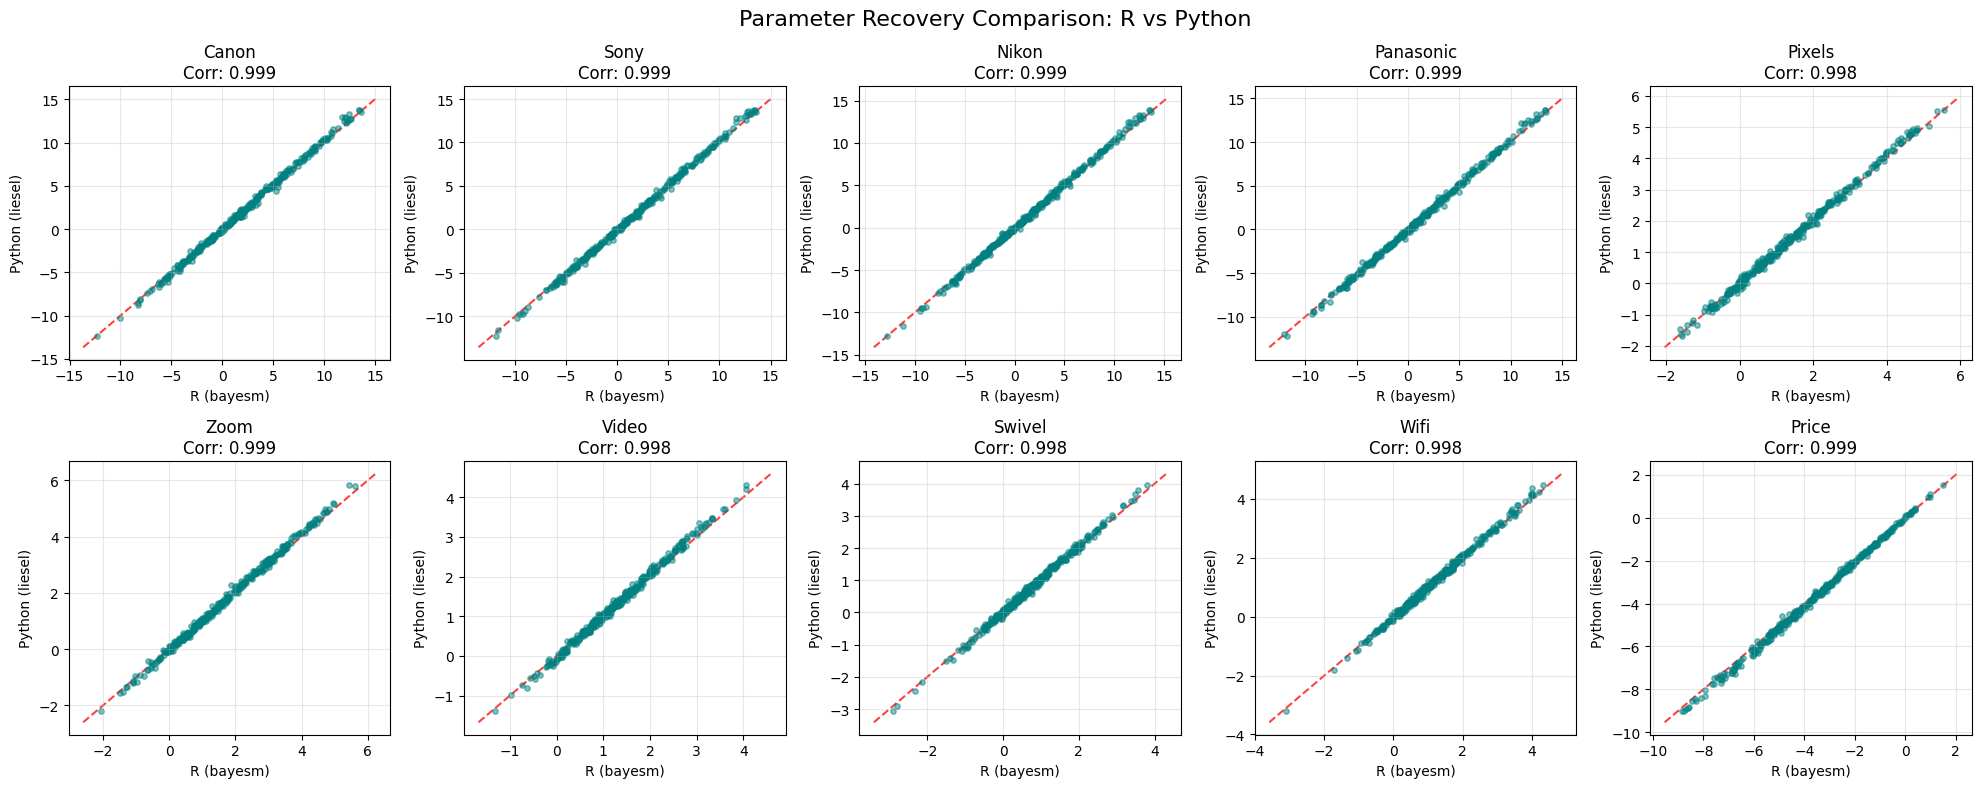

In [13]:
# 1. Load R Estimates
# We use "../Data" because the notebook is in "Python" and needs to go up one level
try:
    r_betas_df = pd.read_csv("../Data/R_beta_estimates.csv")
    print("Successfully loaded R estimates.")
except FileNotFoundError:
    print("Error: Could not find R_beta_estimates.csv. Make sure you ran the R script first!")

# 2. Extract Python Estimates from the current session
# We take the mean over chains (axis 0) and samples (axis 1)
py_betas = np.array(jnp.mean(samples["beta_i"], axis=(0, 1))) 

# Convert R data to numpy for easy plotting
r_betas = r_betas_df.values 

# Parameter Names
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]

# 3. Plot Comparison
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, param in enumerate(param_names):
    ax = axes[i]
    
    x_val = r_betas[:, i] # R
    y_val = py_betas[:, i] # Python
    
    # Calculate Correlation
    corr = np.corrcoef(x_val, y_val)[0, 1]
    
    # Scatter plot
    ax.scatter(x_val, y_val, alpha=0.5, s=15, color='teal')
    
    # Diagonal reference line (Perfect match line)
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
    
    ax.set_title(f"{param}\nCorr: {corr:.3f}")
    ax.set_xlabel("R (bayesm)")
    ax.set_ylabel("Python (liesel)")
    ax.grid(True, alpha=0.3)

plt.suptitle("Parameter Recovery Comparison: R vs Python", fontsize=16)
plt.tight_layout()
plt.show()

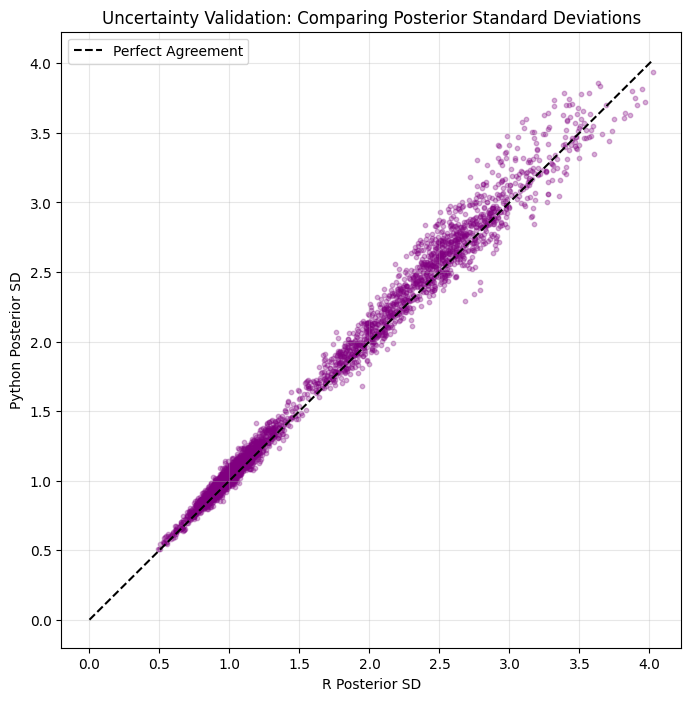

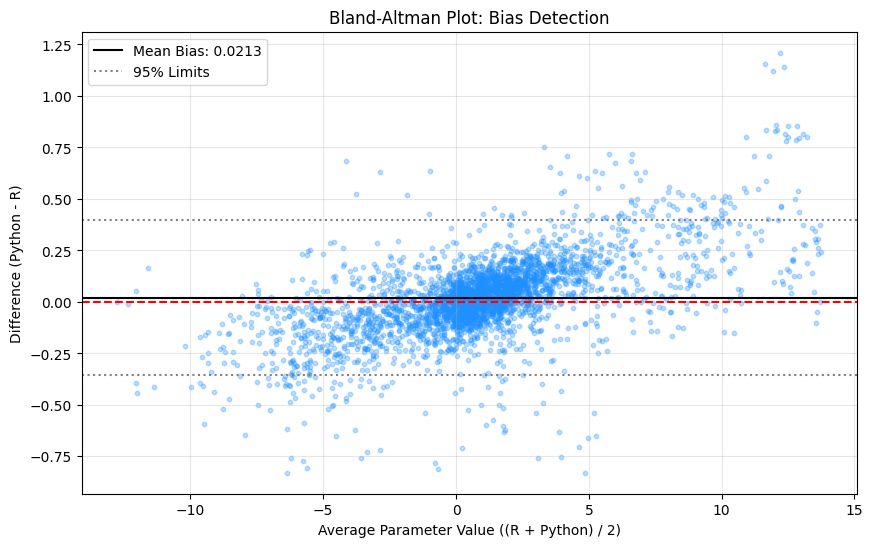


=== Global Population Parameter Comparison ===


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_17760\386053155.py:82: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(df_global.style.applymap(highlight_diff, subset=['Diff']))


,Parameter,R_Mu,Python_Mu,Diff
0,Canon,1.955576,2.008490,0.052914
1,Sony,1.562748,1.575879,0.013131
2,Nikon,1.671456,1.702113,0.030658
3,Panasonic,1.176321,1.179851,0.003530
4,Pixels,1.385240,1.427664,0.042424
5,Zoom,1.700860,1.753816,0.052956
6,Video,1.300933,1.336617,0.035685
7,Swivel,0.727915,0.765696,0.037781
8,Wifi,1.183111,1.201330,0.018220
9,Price,-3.484149,-3.581036,-0.096887


In [14]:
# ==============================================================================
# SETUP: LOAD DATA
# ==============================================================================
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]

# Load R Data
try:
    r_means = pd.read_csv("../Data/R_beta_estimates.csv").values
    r_sds   = pd.read_csv("../Data/R_beta_sds.csv").values
    r_mu    = pd.read_csv("../Data/R_mu_means.csv").values.flatten()
except FileNotFoundError:
    print("Error: Missing R export files. Please run Step 1 in R first.")

# Extract Python Data
# Means: (Units, Params)
py_means = np.array(jnp.mean(samples["beta_i"], axis=(0, 1)))
# SDs: (Units, Params) - The standard deviation across MCMC draws
py_sds   = np.array(jnp.std(samples["beta_i"], axis=(0, 1)))
# Global Mu: (Params)
py_mu    = np.array(jnp.mean(samples["mu"], axis=(0, 1)))

# ==============================================================================
# ANALYSIS 1: UNCERTAINTY COMPARISON (Do models agree on confidence?)
# ==============================================================================
# If points are below the diagonal, Python is more confident (smaller SD) than R.
# If points are above, Python is less confident.

plt.figure(figsize=(8, 8))
plt.scatter(r_sds.flatten(), py_sds.flatten(), alpha=0.3, color='purple', s=10)
plt.plot([0, np.max(r_sds)], [0, np.max(r_sds)], 'k--', label="Perfect Agreement")
plt.xlabel("R Posterior SD")
plt.ylabel("Python Posterior SD")
plt.title("Uncertainty Validation: Comparing Posterior Standard Deviations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==============================================================================
# ANALYSIS 2: BLAND-ALTMAN PLOT (Systematic Bias Detection)
# ==============================================================================
# We plot the MEAN of the two methods (x-axis) vs the DIFFERENCE (y-axis).
# This helps us see if the error gets bigger when the value gets bigger.

diffs = py_means - r_means
means = (py_means + r_means) / 2

plt.figure(figsize=(10, 6))
plt.scatter(means.flatten(), diffs.flatten(), alpha=0.3, color='dodgerblue', s=10)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(np.mean(diffs), color='black', linestyle='-', label=f'Mean Bias: {np.mean(diffs):.4f}')

# Add 95% limits of agreement (Mean +/- 1.96 SD)
std_diff = np.std(diffs)
plt.axhline(np.mean(diffs) + 1.96*std_diff, color='gray', linestyle=':', label='95% Limits')
plt.axhline(np.mean(diffs) - 1.96*std_diff, color='gray', linestyle=':')

plt.title("Bland-Altman Plot: Bias Detection")
plt.xlabel("Average Parameter Value ((R + Python) / 2)")
plt.ylabel("Difference (Python - R)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==============================================================================
# ANALYSIS 3: POPULATION RECOVERY TABLE
# ==============================================================================
# Direct side-by-side comparison of the Global Mu vector

df_global = pd.DataFrame({
    'Parameter': param_names,
    'R_Mu': r_mu,
    'Python_Mu': py_mu,
    'Diff': py_mu - r_mu
})

# Highlight big differences
def highlight_diff(val):
    color = 'red' if abs(val) > 0.1 else 'black'
    return 'color: %s' % color

print("\n=== Global Population Parameter Comparison ===")
display(df_global.style.applymap(highlight_diff, subset=['Diff']))

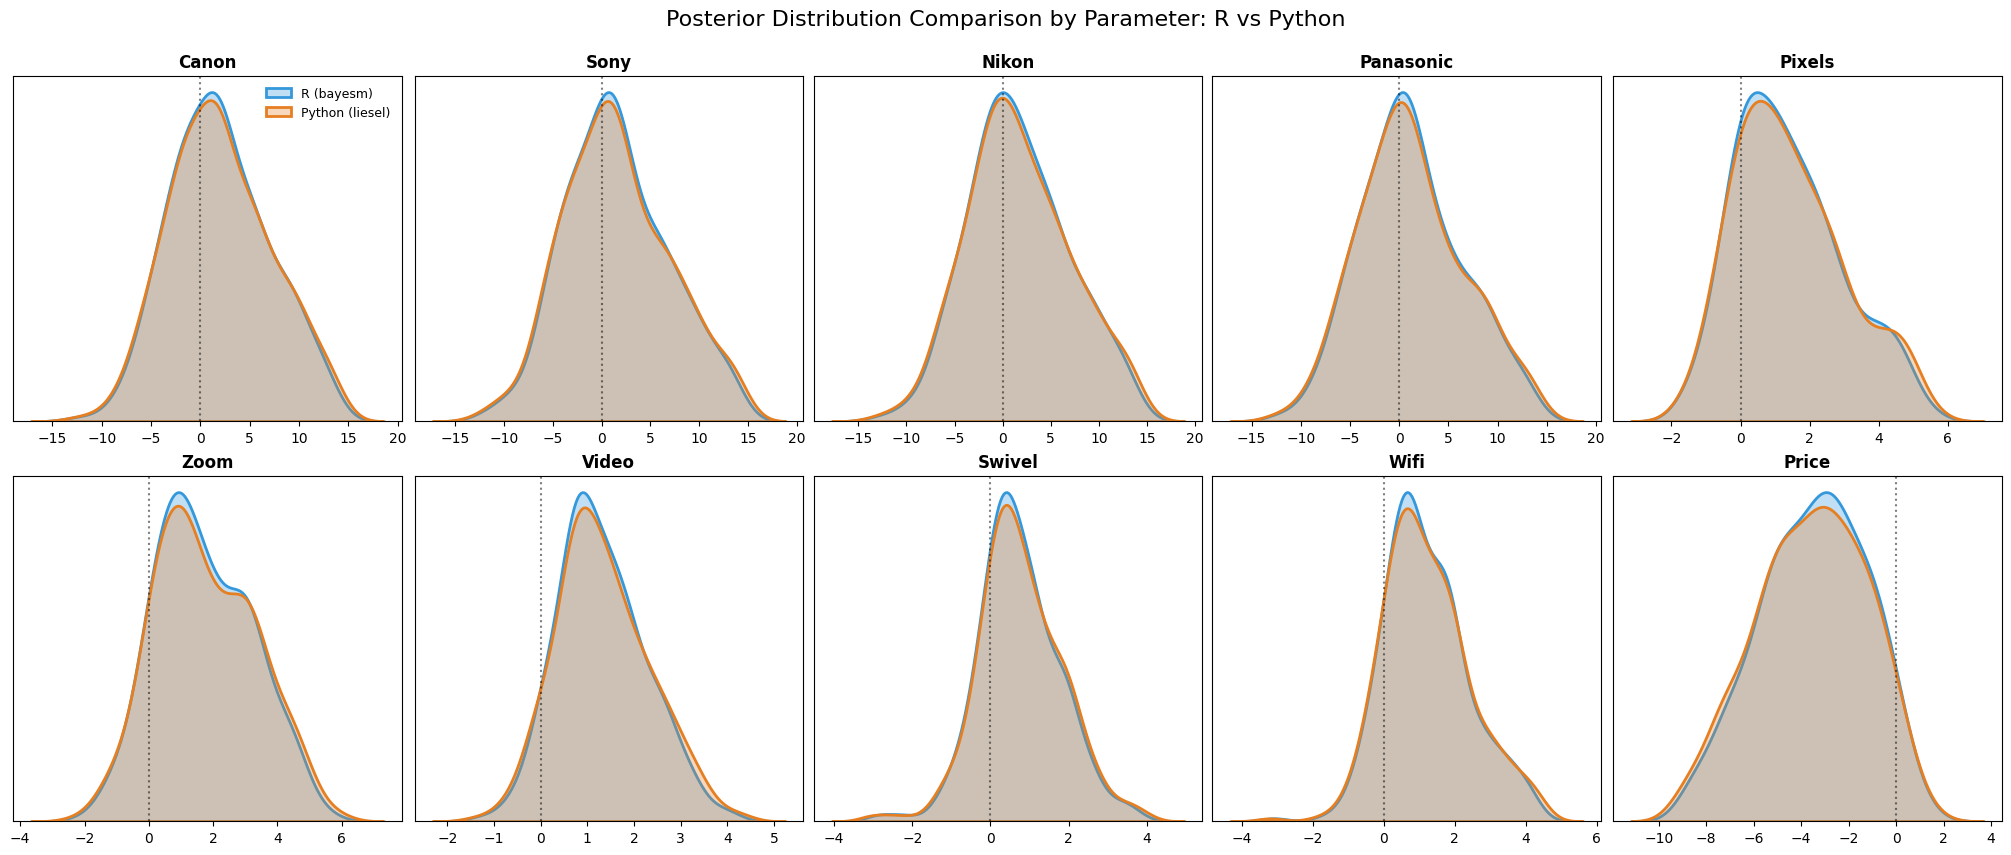

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==============================================================================
# SETUP: LOAD DATA
# ==============================================================================
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]

# 1. Load R Estimates (Individual Betas)
try:
    # Ensure this path matches where your R script saved the file
    r_betas_df = pd.read_csv("../Data/R_beta_estimates.csv")
    r_betas = r_betas_df.values
except FileNotFoundError:
    print("Error: Could not find R_beta_estimates.csv. Run the R export step first.")

# 2. Extract Python Estimates (Individual Betas)
# Mean over chains and samples -> Shape: (332 units, 10 params)
py_betas = np.array(jnp.mean(samples["beta_i"], axis=(0, 1)))

# ==============================================================================
# VISUALIZATION: GRID OF DENSITY PLOTS
# ==============================================================================
# We create a 2x5 grid to show all 10 parameters simultaneously

fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
axes = axes.flatten() # Flattens the 2D grid into a 1D list for easy looping

for i, param in enumerate(param_names):
    ax = axes[i]
    
    # Extract data for this specific parameter
    r_data = r_betas[:, i]
    py_data = py_betas[:, i]
    
    # Plot R Distribution (Blue, shaded)
    sns.kdeplot(r_data, ax=ax, fill=True, color="#3498db", alpha=0.3, label="R (bayesm)", linewidth=2)
    
    # Plot Python Distribution (Orange, shaded)
    sns.kdeplot(py_data, ax=ax, fill=True, color="#e67e22", alpha=0.3, label="Python (liesel)", linewidth=2)
    
    # Formatting
    ax.set_title(f"{param}", fontsize=12, fontweight='bold')
    ax.set_ylabel("") # Remove y-label to reduce clutter
    ax.set_yticks([]) # Remove y-ticks (density values aren't usually interpretable)
    
    # Add a zero line for reference
    ax.axvline(0, color='black', linestyle=':', alpha=0.5)

# Add a single legend to the top right (or first plot)
axes[0].legend(loc='upper right', frameon=False, fontsize=9)

plt.suptitle("Posterior Distribution Comparison by Parameter: R vs Python", fontsize=16, y=1.05)
plt.show()